In [1]:
# -*- coding: utf-8 -*-
"""
Utility: print example prompts from generated JSON files (prompts/).
- For each of the target days [0, 20, 40, 60, 80, 100, 120], if a JSON exists,
  randomly sample one entry from patients and caregivers and print the full prompt.
- You can also call `print_one(file_path, pid=None)` to print a specific file (and optional participant id).

Run in a Jupyter notebook cell.
"""

import json
import random
from pathlib import Path
from typing import Optional, Dict
from huggingface_hub import snapshot_download

# ---------- Config ----------
HF_REPO_ID = "nichenshun/rdmap_prompts_vanilla"  
HF_CACHE_DIR = Path("./hf_cache")  

PROMPTS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

TARGET_DAYS = [0, 20, 40, 60, 80, 100, 120]
ROLES = ["patients", "caregivers"]
SEED = 2025  # for reproducibility of random sampling
random.seed(SEED)

def load_json(path: Path) -> Optional[Dict[str, str]]:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as f:
        data = json.load(f)
    if not isinstance(data, dict):
        raise ValueError(f"JSON at {path} is not a dict of id -> prompt.")
    return data

def print_divider(title: str = "", char: str = "=", width: int = 100):
    line = char * width
    if title:
        print(f"\n{line}\n{title}\n{line}")
    else:
        print(f"\n{line}")

def print_one(file_path: Path, pid: Optional[str] = None):
    """
    Print one prompt from a given file.
    - If pid is None, randomly pick one id
    - If pid is provided but not found, raise KeyError
    """
    data = load_json(file_path)
    if data is None:
        print(f"[WARN] File not found: {file_path}")
        return

    if not data:
        print(f"[WARN] File exists but empty: {file_path}")
        return

    if pid is None:
        pid = random.choice(list(data.keys()))
    elif pid not in data:
        raise KeyError(f"pid {pid} not found in {file_path}")

    prompt = data[pid]
    print_divider(f"FILE: {file_path.name} | PID: {pid}")
    print(prompt)

def print_random_examples(prompts_dir: Path = PROMPTS_DIR,
                          roles = ROLES,
                          target_days = TARGET_DAYS,
                          sample_per_file: int = 1):
    """
    For each role/day file that exists, print `sample_per_file` random prompts.
    """
    for role in roles:
        for day in target_days:
            file_path = prompts_dir / f"{role}_day{day}.json"
            data = load_json(file_path)
            if data is None:
                # File missing, skip quietly
                continue
            if not data:
                print(f"[WARN] Empty JSON: {file_path}")
                continue

            ids = list(data.keys())
            # If the file has fewer than requested, adjust
            k = min(sample_per_file, len(ids))
            picked = random.sample(ids, k=k)
            for pid in picked:
                print_divider(f"FILE: {file_path.name} | PID: {pid}")
                print(data[pid])

# ---------- Usage examples ----------

# 1) Print one random example per available role/day file:
print_random_examples(sample_per_file=1)

# 2) (Optional) Print one specific file with random id:
# print_one(PROMPTS_DIR / "patients_day20.json")

# 3) (Optional) Print one specific participant from a file:
# print_one(PROMPTS_DIR / "patients_day20.json", pid="P094")


/nas/longleaf/home/chenshun/conda/miniconda/envs/jitai/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 30 files: 100%|██████████| 30/30 [00:00<00:00, 34.15it/s]


FILE: patients_day0.json | PID: P115
You are a patient participant in a dyad in the ROADMAP 2.0 mobile-health study. 

You are a patient recovering from a hematopoietic cell transplantation (HCT) to treat a blood-related disease such as leukemia or lymphoma. During recovery, you may experience fatigue, nausea, pain, sleep disturbances, and emotional stress, while relying on your care partner and medical team to help you regain strength and prevent complications like infections or graft-versus-host disease. 

Each day, you are asked to enter your mood on a 1-10 scale (1=worst, 10=best). 

The study seeks to understand links between sensor data and well-being and to support caregivers during and after transplant. 

Each time step in this simulation represents one day.

- **Your Background:**
- You are in the 18-39 age group.
- Your gender is male.
- You are assigned to the Intervention arm of the study.
- Your transplant type is Autologous.
- You stayed in the hospital for 14 days.
- Yo

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 34.71it/s]


[INFO] patients day 0: TP=19, FP=41, TN=1, FN=0, TPR=1.000 FPR=0.976 ACC=0.328 CE=1.055
[INFO] patients day 20: TP=31, FP=10, TN=54, FN=5, TPR=0.861 FPR=0.156 ACC=0.850 CE=0.405
[INFO] patients day 40: TP=33, FP=16, TN=48, FN=3, TPR=0.917 FPR=0.250 ACC=0.810 CE=0.450
[INFO] patients day 60: TP=29, FP=18, TN=46, FN=7, TPR=0.806 FPR=0.281 ACC=0.750 CE=0.490
[INFO] patients day 80: TP=28, FP=20, TN=51, FN=1, TPR=0.966 FPR=0.282 ACC=0.790 CE=0.479
[INFO] patients day 100: TP=29, FP=14, TN=56, FN=1, TPR=0.967 FPR=0.200 ACC=0.850 CE=0.407
[INFO] patients day 120: TP=25, FP=11, TN=58, FN=5, TPR=0.833 FPR=0.159 ACC=0.838 CE=0.428
[INFO] caregivers day 0: TP=52, FP=46, TN=1, FN=1, TPR=0.981 FPR=0.979 ACC=0.530 CE=0.861
[INFO] caregivers day 20: TP=50, FP=17, TN=26, FN=7, TPR=0.877 FPR=0.395 ACC=0.760 CE=0.540
[INFO] caregivers day 40: TP=59, FP=8, TN=31, FN=2, TPR=0.967 FPR=0.205 ACC=0.900 CE=0.324
[INFO] caregivers day 60: TP=43, FP=20, TN=32, FN=5, TPR=0.896 FPR=0.385 ACC=0.750 CE=0.494
[INFO

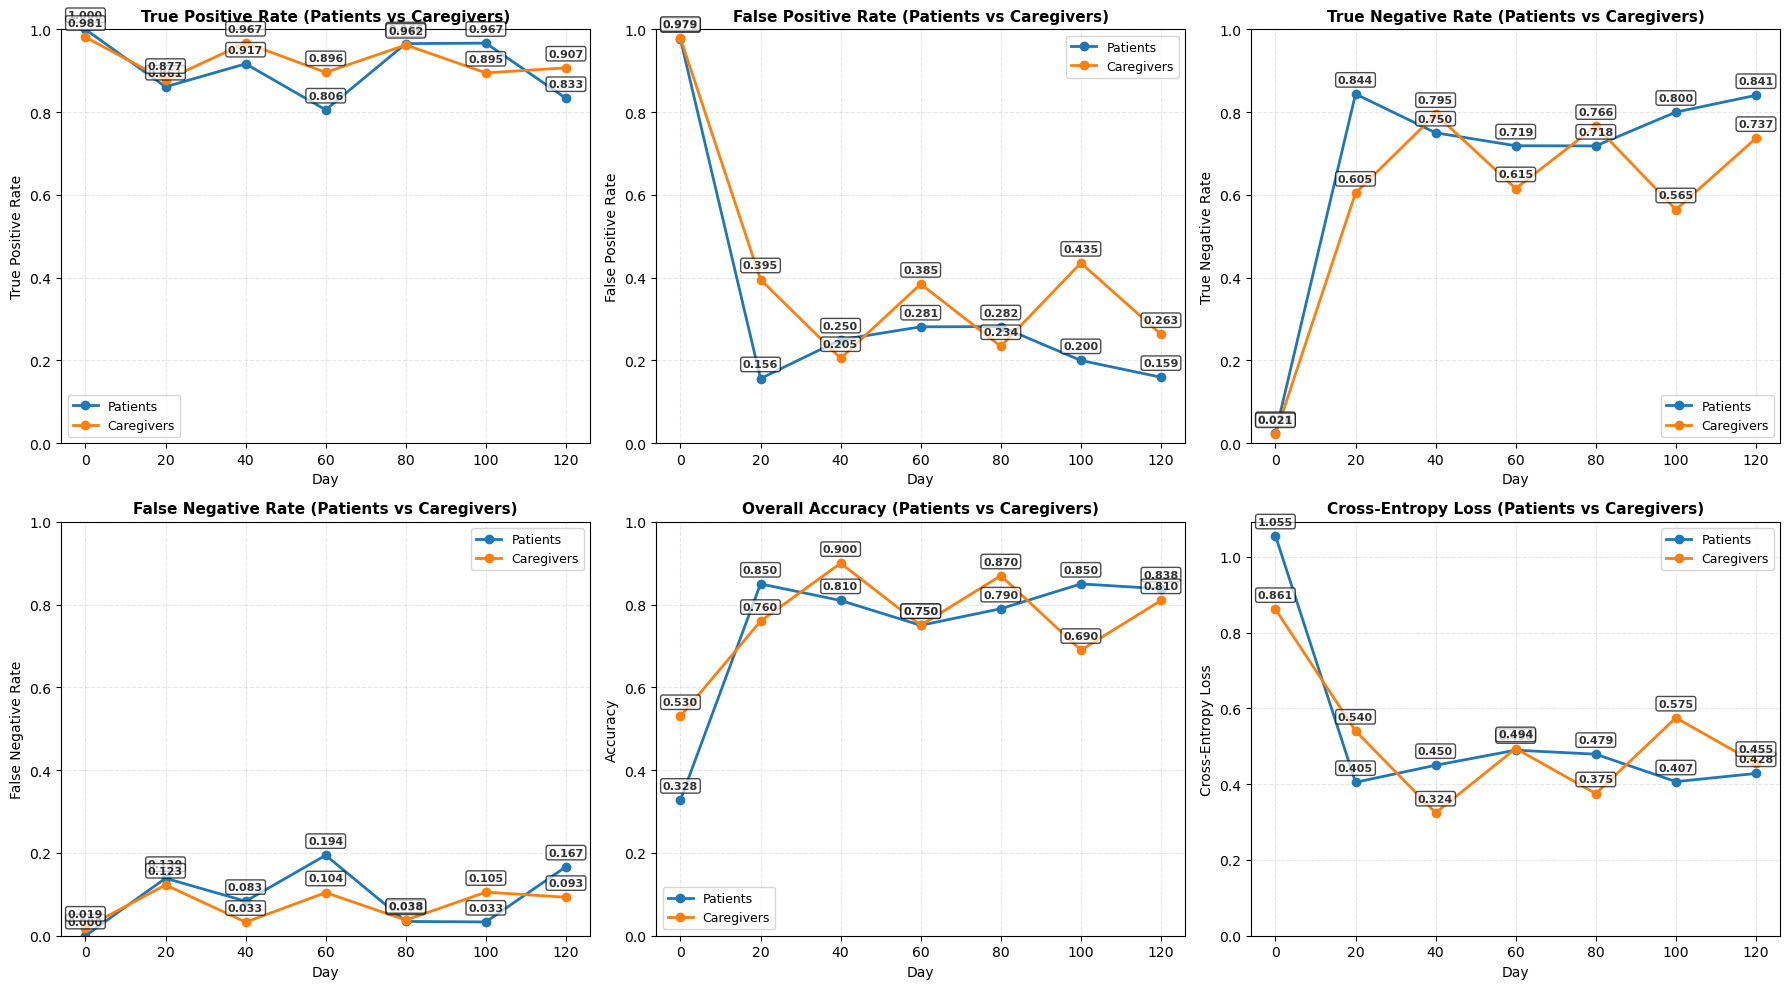


SUMMARY STATISTICS BY ROLE (VANILLA PREDICTIONS)

Patients:
----------------------------------------
  True Positive Rate: 0.907 ± 0.075
  False Positive Rate: 0.329 ± 0.290
  True Negative Rate: 0.671 ± 0.290
  False Negative Rate: 0.093 ± 0.075
  Accuracy: 0.745 ± 0.188
  Cross-Entropy: 0.530 ± 0.234

Caregivers:
----------------------------------------
  True Positive Rate: 0.926 ± 0.042
  False Positive Rate: 0.414 ± 0.264
  True Negative Rate: 0.586 ± 0.264
  False Negative Rate: 0.074 ± 0.042
  Accuracy: 0.759 ± 0.124
  Cross-Entropy: 0.518 ± 0.175

CONFUSION MATRIX SUMMARY (VANILLA PREDICTIONS)

Patients:
----------------------------------------
  Total TP: 194
  Total FP: 130
  Total TN: 314
  Total FN: 22
  Total samples: 660
  Overall Accuracy: 0.770
  Overall Precision: 0.599
  Overall Recall: 0.898
  Overall F1-Score: 0.719

Caregivers:
----------------------------------------
  Total TP: 328
  Total FP: 144
  Total TN: 203
  Total FN: 25
  Total samples: 700
  Overall Acc

In [3]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from huggingface_hub import snapshot_download

# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_vanilla"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_data.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper functions
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Aggregate metrics storage and detailed data collection
# --------------------
metrics = {
    role: {
        "tpr": [],
        "fpr": [],
        "tnr": [],
        "fnr": [],
        "acc": [],
        "ce":  [],
    }
    for role in ROLES
}

# Store detailed data for printing
detailed_data = []

# --------------------
# Main loop: per role × day, compute metrics
# --------------------
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            print(f"[WARN] Missing predictions file: {pred_file}. Metrics will be NaN for {role}, day {day}.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            
            # Store NaN values for detailed data
            detailed_data.append({
                'role': role,
                'day': day,
                'tpr': np.nan,
                'fpr': np.nan,
                'tnr': np.nan,
                'fnr': np.nan,
                'acc': np.nan,
                'ce': np.nan,
                'TP': 0,
                'FP': 0,
                'TN': 0,
                'FN': 0,
                'total': 0
            })
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            print(f"[WARN] Predictions file {pred_file} is not a dict. Metrics will be NaN.")
            metrics[role]["tpr"].append(np.nan)
            metrics[role]["fpr"].append(np.nan)
            metrics[role]["tnr"].append(np.nan)
            metrics[role]["fnr"].append(np.nan)
            metrics[role]["acc"].append(np.nan)
            metrics[role]["ce"].append(np.nan)
            
            detailed_data.append({
                'role': role,
                'day': day,
                'tpr': np.nan,
                'fpr': np.nan,
                'tnr': np.nan,
                'fnr': np.nan,
                'acc': np.nan,
                'ce': np.nan,
                'TP': 0,
                'FP': 0,
                'TN': 0,
                'FN': 0,
                'total': 0
            })
            continue

        # Counters
        TP = FP = TN = FN = 0
        ce_losses = []

        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            conf = info["confidence"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update confusion matrix
            if y_true == 1 and y_hat == 1:
                TP += 1
            elif y_true == 0 and y_hat == 1:
                FP += 1
            elif y_true == 0 and y_hat == 0:
                TN += 1
            elif y_true == 1 and y_hat == 0:
                FN += 1

            # Cross-entropy calculation
            if y_hat == 1:
                p_yes = conf
            else:
                p_yes = 1.0 - conf

            p_yes = max(1e-6, min(1.0 - 1e-6, p_yes))
            ce = -(y_true * np.log(p_yes) + (1 - y_true) * np.log(1 - p_yes))
            ce_losses.append(ce)

        # Compute rates
        P = TP + FN
        N = TN + FP
        total = P + N

        tpr = TP / P if P > 0 else np.nan
        fpr = FP / N if N > 0 else np.nan
        tnr = TN / N if N > 0 else np.nan
        fnr = FN / P if P > 0 else np.nan
        acc = (TP + TN) / total if total > 0 else np.nan
        ce_mean = float(np.mean(ce_losses)) if ce_losses else np.nan

        metrics[role]["tpr"].append(tpr)
        metrics[role]["fpr"].append(fpr)
        metrics[role]["tnr"].append(tnr)
        metrics[role]["fnr"].append(fnr)
        metrics[role]["acc"].append(acc)
        metrics[role]["ce"].append(ce_mean)

        # Store detailed data for printing
        detailed_data.append({
            'role': role,
            'day': day,
            'tpr': tpr,
            'fpr': fpr,
            'tnr': tnr,
            'fnr': fnr,
            'acc': acc,
            'ce': ce_mean,
            'TP': TP,
            'FP': FP,
            'TN': TN,
            'FN': FN,
            'total': total
        })

        print(f"[INFO] {role} day {day}: TP={TP}, FP={FP}, TN={TN}, FN={FN}, "
              f"TPR={tpr:.3f} FPR={fpr:.3f} ACC={acc:.3f} CE={ce_mean:.3f}")

# --------------------
# Print detailed point values
# --------------------
print("\n" + "="*100)
print("DETAILED METRIC VALUES FOR ALL POINTS (VANILLA PREDICTIONS)")
print("="*100)

# Convert to DataFrame for easier printing
detailed_df = pd.DataFrame(detailed_data)

# Print table for each metric
metrics_to_print = ['tpr', 'fpr', 'tnr', 'fnr', 'acc', 'ce']
metric_names = {
    'tpr': 'True Positive Rate',
    'fpr': 'False Positive Rate', 
    'tnr': 'True Negative Rate',
    'fnr': 'False Negative Rate',
    'acc': 'Accuracy',
    'ce': 'Cross-Entropy'
}

for metric in metrics_to_print:
    print(f"\n{metric_names[metric].upper()}:")
    print("-" * 60)
    
    # Pivot table for better formatting
    pivot_data = detailed_df.pivot(index='day', columns='role', values=metric)
    
    # Print header
    header = f"{'Day':<4} {'Patients':<12} {'Caregivers':<12}"
    print(header)
    print("-" * len(header))
    
    # Print values for each day
    for day in DAYS:
        if day in pivot_data.index:
            patients_val = pivot_data.loc[day, 'patients'] if 'patients' in pivot_data.columns else np.nan
            caregivers_val = pivot_data.loc[day, 'caregivers'] if 'caregivers' in pivot_data.columns else np.nan
            
            patients_str = f"{patients_val:.3f}" if not np.isnan(patients_val) else "N/A"
            caregivers_str = f"{caregivers_val:.3f}" if not np.isnan(caregivers_val) else "N/A"
            
            print(f"{day:<4} {patients_str:<12} {caregivers_str:<12}")
        else:
            print(f"{day:<4} {'N/A':<12} {'N/A':<12}")

# --------------------
# Plot all metrics in 2x3 grid
# --------------------
def plot_all_metrics_grid(metrics, detailed_df):
    """Plot all 6 metrics in a 2x3 grid layout with value annotations"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()
    
    metric_configs = [
        ("tpr", "True Positive Rate", "True Positive Rate (Patients vs Caregivers)"),
        ("fpr", "False Positive Rate", "False Positive Rate (Patients vs Caregivers)"),
        ("tnr", "True Negative Rate", "True Negative Rate (Patients vs Caregivers)"),
        ("fnr", "False Negative Rate", "False Negative Rate (Patients vs Caregivers)"),
        ("acc", "Accuracy", "Overall Accuracy (Patients vs Caregivers)"),
        ("ce", "Cross-Entropy Loss", "Cross-Entropy Loss (Patients vs Caregivers)")
    ]
    
    for i, (metric_key, ylabel, title) in enumerate(metric_configs):
        ax = axes[i]
        
        for role in ROLES:
            values = metrics[role][metric_key]
            ax.plot(DAYS, values, marker="o", linewidth=2, markersize=6, 
                   label=role.capitalize())
            
            # Add value annotations
            for j, (day, value) in enumerate(zip(DAYS, values)):
                if not np.isnan(value):
                    ax.annotate(f'{value:.3f}', 
                               (day, value),
                               textcoords="offset points",
                               xytext=(0,8),
                               ha='center',
                               fontsize=8,
                               alpha=0.8,
                               fontweight='bold',
                               bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.set_xlabel("Day", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.grid(True, linestyle="--", alpha=0.3)
        ax.legend(fontsize=9)
        ax.set_xticks(DAYS)
        
        # Set appropriate y-axis limits
        if metric_key == 'ce':
            ax.set_ylim(bottom=0)
        else:
            ax.set_ylim(0, 1)
    
    plt.tight_layout()
    plt.show()

# Generate the grid plot
plot_all_metrics_grid(metrics, detailed_df)

# --------------------
# Print summary statistics
# --------------------
print("\n" + "="*80)
print("SUMMARY STATISTICS BY ROLE (VANILLA PREDICTIONS)")
print("="*80)

for role in ROLES:
    print(f"\n{role.capitalize()}:")
    print("-" * 40)
    
    role_data = detailed_df[detailed_df['role'] == role]
    
    for metric in metrics_to_print:
        values = role_data[metric].dropna()
        if len(values) > 0:
            mean_val = values.mean()
            std_val = values.std()
            print(f"  {metric_names[metric]}: {mean_val:.3f} ± {std_val:.3f}")
        else:
            print(f"  {metric_names[metric]}: No valid data")

# --------------------
# Print confusion matrix summary
# --------------------
print("\n" + "="*80)
print("CONFUSION MATRIX SUMMARY (VANILLA PREDICTIONS)")
print("="*80)

for role in ROLES:
    print(f"\n{role.capitalize()}:")
    print("-" * 40)
    
    role_data = detailed_df[detailed_df['role'] == role]
    total_tp = role_data['TP'].sum()
    total_fp = role_data['FP'].sum()
    total_tn = role_data['TN'].sum()
    total_fn = role_data['FN'].sum()
    total_n = role_data['total'].sum()
    
    print(f"  Total TP: {total_tp}")
    print(f"  Total FP: {total_fp}")
    print(f"  Total TN: {total_tn}")
    print(f"  Total FN: {total_fn}")
    print(f"  Total samples: {total_n}")
    
    if total_n > 0:
        overall_acc = (total_tp + total_tn) / total_n
        print(f"  Overall Accuracy: {overall_acc:.3f}")
        
        # Calculate additional metrics
        precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
        recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        
        print(f"  Overall Precision: {precision:.3f}")
        print(f"  Overall Recall: {recall:.3f}")
        print(f"  Overall F1-Score: {f1:.3f}")

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 32993.54it/s]


DETAILED ACCURACY VALUES FOR EACH DEMOGRAPHIC GROUP (VANILLA PREDICTIONS)

ARM DETAILED ACCURACY VALUES:
Day  Control        Intervention   
-----------------------------------
0    0.475 (80)     0.432 (81)     
20   0.837 (98)     0.775 (102)    
40   0.847 (98)     0.863 (102)    
60   0.704 (98)     0.794 (102)    
80   0.827 (98)     0.833 (102)    
100  0.714 (98)     0.824 (102)    
120  0.835 (97)     0.814 (102)    

GENDER DETAILED ACCURACY VALUES:
Day  Female         Male           
-----------------------------------
0    0.447 (94)     0.463 (67)     
20   0.792 (106)    0.819 (94)     
40   0.877 (106)    0.830 (94)     
60   0.745 (106)    0.755 (94)     
80   0.849 (106)    0.809 (94)     
100  0.726 (106)    0.819 (94)     
120  0.774 (106)    0.882 (93)     

TRANSPLANT_TYPE DETAILED ACCURACY VALUES:
Day  Allogeneic     Autologous     
-----------------------------------
0    0.505 (101)    0.367 (60)     
20   0.831 (124)    0.763 (76)     
40   0.863 (124)    0.842 

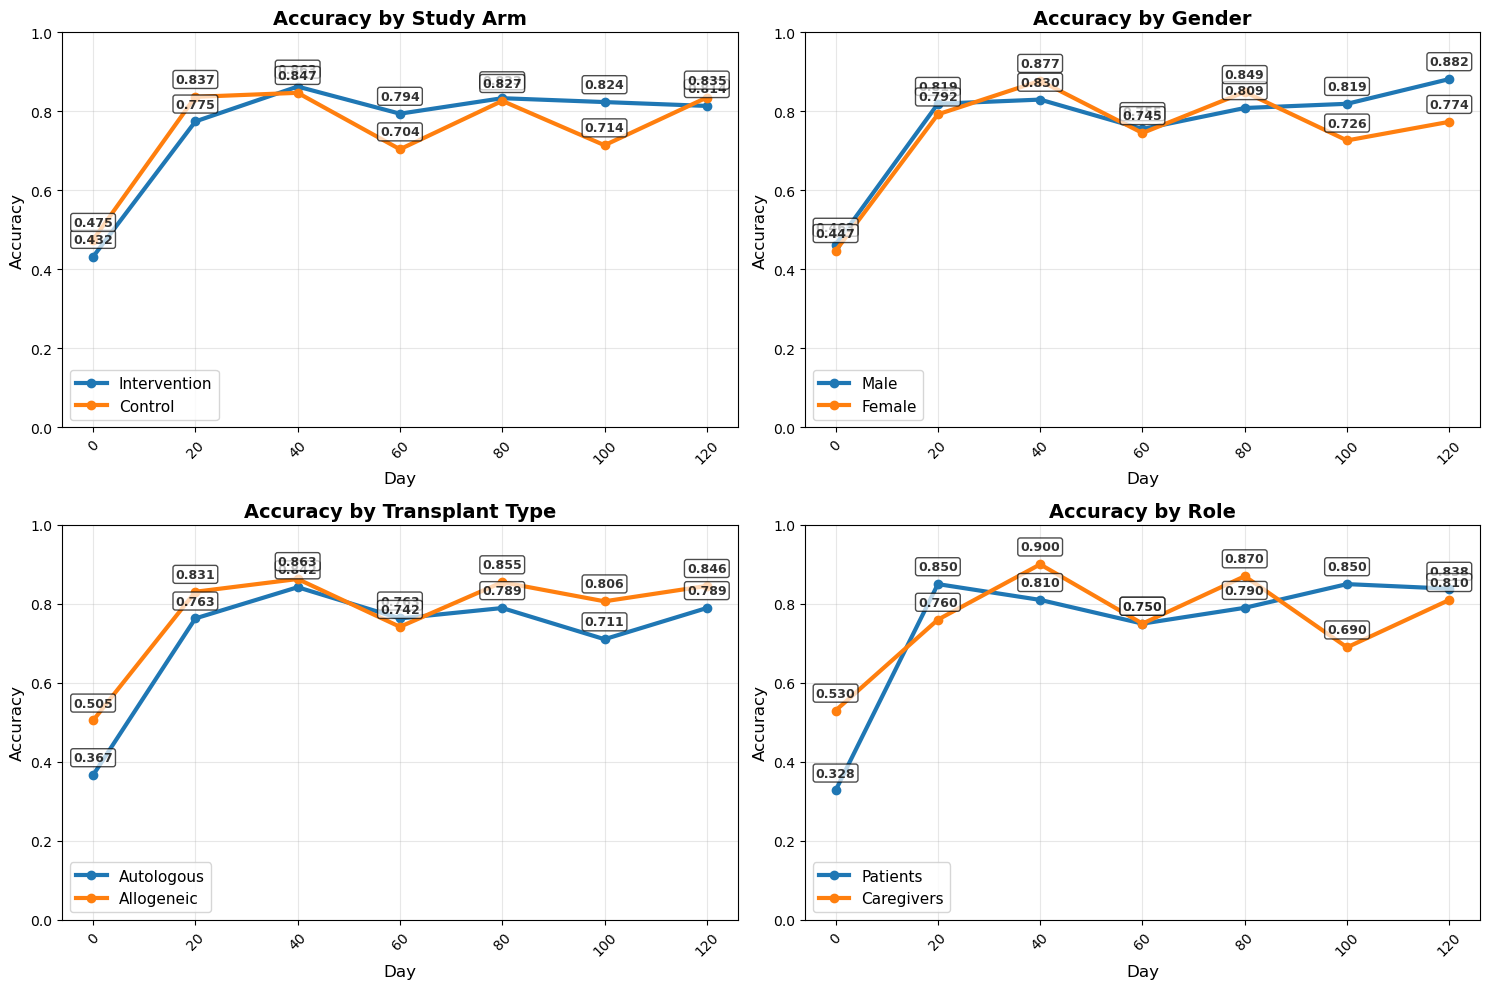


OVERALL ACCURACY SUMMARY BY DEMOGRAPHIC GROUPS (VANILLA PREDICTIONS)

ARM ANALYSIS:
----------------------------------------
  Intervention:
    Average: 0.762 ± 0.148
    Range: 0.432 - 0.863
    Total predictions: 693
  Control:
    Average: 0.748 ± 0.135
    Range: 0.475 - 0.847
    Total predictions: 667

GENDER ANALYSIS:
----------------------------------------
  Male:
    Average: 0.768 ± 0.140
    Range: 0.463 - 0.882
    Total predictions: 630
  Female:
    Average: 0.744 ± 0.142
    Range: 0.447 - 0.877
    Total predictions: 730

TRANSPLANT_TYPE ANALYSIS:
----------------------------------------
  Allogeneic:
    Average: 0.778 ± 0.127
    Range: 0.505 - 0.863
    Total predictions: 844
  Autologous:
    Average: 0.718 ± 0.160
    Range: 0.367 - 0.842
    Total predictions: 516

ROLE ANALYSIS:
----------------------------------------
  Caregivers:
    Average: 0.759 ± 0.124
    Range: 0.530 - 0.900
    Total predictions: 700
  Patients:
    Average: 0.745 ± 0.188
    Range: 

In [5]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------
# Config
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_vanilla"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

ROLES = ["patients", "caregivers"]
DAYS = [0, 20, 40, 60, 80, 100, 120]

# --------------------
# Load participants_data.json
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper functions
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

def get_demographic_info(pid: str) -> Dict[str, str]:
    """Extract demographic information for a participant"""
    node = participants.get(pid, {})
    demo = node.get("Demographic", {}) or {}
    
    return {
        "arm": demo.get("arm", "Unknown"),
        "gender": demo.get("gender", "Unknown"), 
        "transplant_type": demo.get("transplant_type", "Unknown"),
        "role": demo.get("role", "Unknown")
    }

# --------------------
# Main analysis: compute accuracy by demographic groups
# --------------------
demographic_metrics = {
    "arm": {},
    "gender": {},
    "transplant_type": {},
    "role": {}
}

# Initialize structure for each demographic category
for category in demographic_metrics:
    demographic_metrics[category] = {}
    for day in DAYS:
        demographic_metrics[category][day] = {}

# Process predictions
for role in ROLES:
    for day in DAYS:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            continue

        for pid, rec in preds_dict.items():
            # Get demographic info
            demo_info = get_demographic_info(pid)
            
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Update accuracy counts for each demographic category
            for category, value in demo_info.items():
                if category not in demographic_metrics:
                    continue
                    
                if value not in demographic_metrics[category][day]:
                    demographic_metrics[category][day][value] = {
                        'correct': 0,
                        'total': 0
                    }
                
                # Check if prediction is correct
                if y_hat == y_true:
                    demographic_metrics[category][day][value]['correct'] += 1
                demographic_metrics[category][day][value]['total'] += 1

# --------------------
# Prepare data for plotting and printing
# --------------------
def prepare_accuracy_data(demographic_metrics):
    """Convert metrics to DataFrame for plotting and printing"""
    accuracy_data = []
    
    for category in demographic_metrics:
        for day in DAYS:
            for group_name, group_data in demographic_metrics[category][day].items():
                if group_data['total'] > 0:
                    accuracy = group_data['correct'] / group_data['total']
                    accuracy_data.append({
                        'category': category,
                        'day': day,
                        'group': group_name,
                        'accuracy': accuracy,
                        'correct': group_data['correct'],
                        'total': group_data['total']
                    })
    
    return pd.DataFrame(accuracy_data)

accuracy_df = prepare_accuracy_data(demographic_metrics)

# --------------------
# Print detailed point values for each demographic group
# --------------------
print("=" * 100)
print("DETAILED ACCURACY VALUES FOR EACH DEMOGRAPHIC GROUP (VANILLA PREDICTIONS)")
print("=" * 100)

for category in ['arm', 'gender', 'transplant_type', 'role']:
    print(f"\n{category.upper()} DETAILED ACCURACY VALUES:")
    print("=" * 60)
    
    category_data = accuracy_df[accuracy_df['category'] == category]
    groups = sorted([g for g in category_data['group'].unique() if g not in ['Unknown', 'None']])
    
    # Print header
    header = f"{'Day':<4} " + "".join([f"{group:<15}" for group in groups])
    print(header)
    print("-" * len(header))
    
    # Print values for each day
    for day in DAYS:
        day_data = category_data[category_data['day'] == day]
        day_values = []
        
        for group in groups:
            group_day_data = day_data[day_data['group'] == group]
            if len(group_day_data) > 0:
                accuracy = group_day_data['accuracy'].values[0]
                total = group_day_data['total'].values[0]
                day_values.append(f"{accuracy:.3f} ({total})")
            else:
                day_values.append("N/A")
        
        row = f"{day:<4} " + "".join([f"{val:<15}" for val in day_values])
        print(row)

# --------------------
# Plot overall accuracy by demographic groups (2x2 grid)
# --------------------
def plot_demographic_accuracy_grid(accuracy_df):
    """Plot overall accuracy by different demographic categories in 2x2 grid"""
    
    # Define colors for different groups
    color_palettes = {
        'arm': ['#1f77b4', '#ff7f0e'],  # Intervention, Control
        'gender': ['#1f77b4', '#ff7f0e'],  # Male, Female
        'transplant_type': ['#1f77b4', '#ff7f0e'],  # Autologous, Allogeneic
        'role': ['#1f77b4', '#ff7f0e']  # Patients, Caregivers
    }
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    axes = axes.flatten()
    
    categories = ['arm', 'gender', 'transplant_type', 'role']
    titles = {
        'arm': 'Accuracy by Study Arm',
        'gender': 'Accuracy by Gender', 
        'transplant_type': 'Accuracy by Transplant Type',
        'role': 'Accuracy by Role'
    }
    
    group_labels = {
        'arm': ['Intervention', 'Control'],
        'gender': ['Male', 'Female'],
        'transplant_type': ['Autologous', 'Allogeneic'],
        'role': ['Patients', 'Caregivers']
    }
    
    for i, category in enumerate(categories):
        ax = axes[i]
        category_data = accuracy_df[accuracy_df['category'] == category]
        
        # Get groups for this category
        groups = [g for g in group_labels[category] if g in category_data['group'].unique()]
        
        # Plot each group
        for j, group in enumerate(groups):
            group_data = category_data[category_data['group'] == group].sort_values('day')
            color = color_palettes[category][j % len(color_palettes[category])]
            
            ax.plot(group_data['day'], group_data['accuracy'], 
                   marker='o', linewidth=3, markersize=6, label=group, color=color)
            
            # Add value labels on each point
            for _, row in group_data.iterrows():
                ax.annotate(f'{row["accuracy"]:.3f}', 
                           (row['day'], row['accuracy']),
                           textcoords="offset points",
                           xytext=(0,10),
                           ha='center',
                           fontsize=9,
                           alpha=0.8,
                           fontweight='bold',
                           bbox=dict(boxstyle="round,pad=0.2", facecolor="white", alpha=0.7))
        
        ax.set_title(titles[category], fontsize=14, fontweight='bold')
        ax.set_xlabel('Day', fontsize=12)
        ax.set_ylabel('Accuracy', fontsize=12)
        ax.grid(True, alpha=0.3)
        ax.legend(fontsize=11)
        ax.set_xticks(DAYS)
        ax.set_ylim(0, 1)
        
        # Improve x-axis labels
        ax.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

# Generate the grid plot
plot_demographic_accuracy_grid(accuracy_df)

# --------------------
# Print summary statistics
# --------------------
print("\n" + "=" * 80)
print("OVERALL ACCURACY SUMMARY BY DEMOGRAPHIC GROUPS (VANILLA PREDICTIONS)")
print("=" * 80)

for category in ['arm', 'gender', 'transplant_type', 'role']:
    print(f"\n{category.upper()} ANALYSIS:")
    print("-" * 40)
    
    category_data = accuracy_df[accuracy_df['category'] == category]
    group_stats = category_data.groupby('group').agg({
        'accuracy': ['mean', 'std', 'min', 'max'],
        'total': 'sum'
    }).round(3)
    
    group_stats.columns = ['avg_accuracy', 'std_accuracy', 'min_accuracy', 'max_accuracy', 'total_predictions']
    group_stats = group_stats.reset_index()
    group_stats = group_stats.sort_values('avg_accuracy', ascending=False)
    
    for _, row in group_stats.iterrows():
        if row['group'] not in ['Unknown', 'None']:
            print(f"  {row['group']}:")
            print(f"    Average: {row['avg_accuracy']:.3f} ± {row['std_accuracy']:.3f}")
            print(f"    Range: {row['min_accuracy']:.3f} - {row['max_accuracy']:.3f}")
            print(f"    Total predictions: {row['total_predictions']:,}")

Fetching 16 files: 100%|██████████| 16/16 [00:00<00:00, 138368.79it/s]


Day 0: Accuracy = 0.453 (73/161 correct)
Day 10: Accuracy = nan (0/0 correct)
Day 20: Accuracy = 0.805 (161/200 correct)
Day 30: Accuracy = nan (0/0 correct)
Day 40: Accuracy = 0.855 (171/200 correct)
Day 50: Accuracy = nan (0/0 correct)
Day 60: Accuracy = 0.750 (150/200 correct)
Day 70: Accuracy = nan (0/0 correct)
Day 80: Accuracy = 0.830 (166/200 correct)
Day 90: Accuracy = nan (0/0 correct)
Day 100: Accuracy = 0.770 (154/200 correct)
Day 110: Accuracy = nan (0/0 correct)
Day 120: Accuracy = 0.824 (164/199 correct)

OVERALL ACCURACY ACROSS ALL PARTICIPANTS
Day  Accuracy   Correct/Total  
-----------------------------------
0.0  0.453     73.0/161.0     
10.0 N/A        N/A            
20.0 0.805     161.0/200.0     
30.0 N/A        N/A            
40.0 0.855     171.0/200.0     
50.0 N/A        N/A            
60.0 0.750     150.0/200.0     
70.0 N/A        N/A            
80.0 0.830     166.0/200.0     
90.0 N/A        N/A            
100.0 0.770     154.0/200.0     
110.0 N/A     

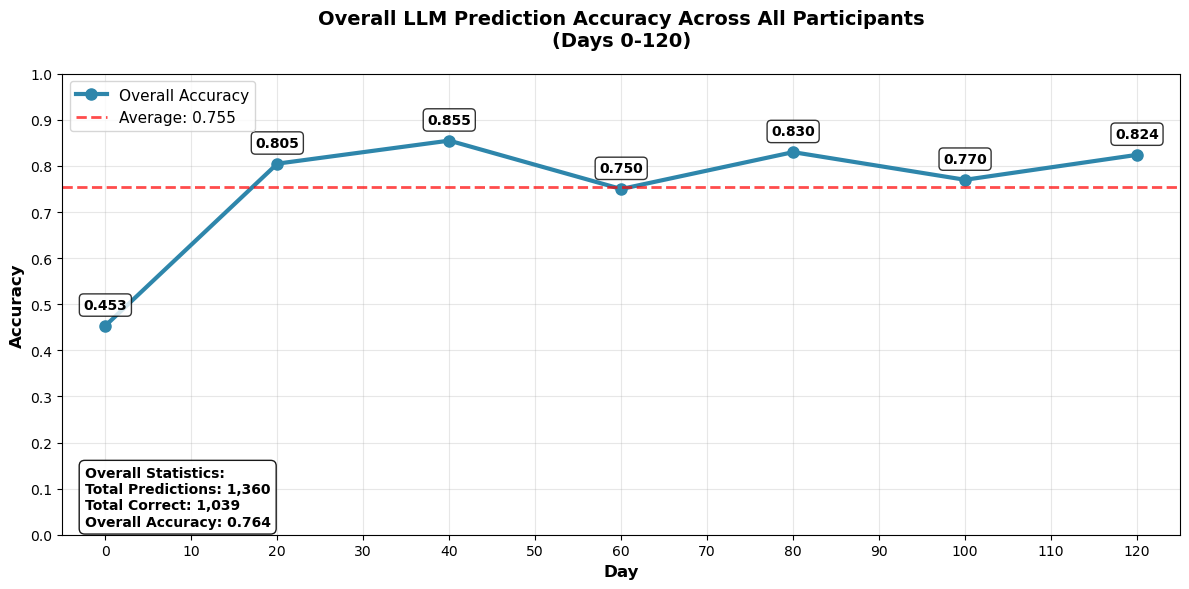


SUMMARY STATISTICS
Average Accuracy: 0.755
Overall Accuracy: 0.764
Total Predictions: 1,360
Total Correct Predictions: 1,039
Days with Data: 7 out of 13
Accuracy Range: 0.453 - 0.855


In [6]:
import json
from pathlib import Path
from typing import Dict, Any, Optional
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --------------------
# Configuration
# --------------------
PARTICIPANTS_JSON_PATH = "participants_data.json"
HF_REPO_ID = "nichenshun/rdmap_predictions_vanilla"  
HF_CACHE_DIR = Path("./hf_cache")  

PREDICTIONS_DIR = Path(snapshot_download(  
    repo_id=HF_REPO_ID,
    repo_type="dataset",
    cache_dir=HF_CACHE_DIR,
))

# Target days for analysis
DAYS = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120]

# --------------------
# Load participants data
# --------------------
with open(PARTICIPANTS_JSON_PATH, "r", encoding="utf-8") as f:
    participants = json.load(f)

if not isinstance(participants, dict):
    raise ValueError("participants_data.json must be a dict keyed by participant ID.")

# --------------------
# Helper functions
# --------------------
def get_actual_label(pid: str, day: int) -> Optional[int]:
    """Get ground truth label for a participant on a specific day."""
    node = participants.get(pid, {})
    mood_map = node.get("Mood", {}) or {}
    if not isinstance(mood_map, dict):
        return 0

    key = f"Day {day}"
    if key not in mood_map:
        return 0

    val = mood_map[key]
    if isinstance(val, str) and val.strip().lower() == "missing":
        return 0

    return 1

def extract_decision_and_conf(parsed: Dict[str, Any]) -> Optional[Dict[str, Any]]:
    """Extract decision and confidence from LLM response."""
    if not isinstance(parsed, dict):
        return None

    dec_raw = parsed.get("decision")
    conf_raw = parsed.get("confidence")

    if dec_raw is None:
        return None

    dec_str = str(dec_raw).strip().lower()
    if dec_str.startswith("y"):
        y_hat = 1
    elif dec_str.startswith("n"):
        y_hat = 0
    else:
        return None

    try:
        conf = float(conf_raw)
    except Exception:
        conf = 0.5

    conf = max(1e-6, min(1.0 - 1e-6, conf))
    return {"y_hat": y_hat, "confidence": conf}

# --------------------
# Calculate overall accuracy across all participants
# --------------------
accuracy_data = []

for day in DAYS:
    total_correct = 0
    total_predictions = 0
    
    # Process both patients and caregivers predictions
    for role in ["patients", "caregivers"]:
        pred_file = PREDICTIONS_DIR / f"{role}_day{day}_results.json"
        if not pred_file.exists():
            continue

        with pred_file.open("r", encoding="utf-8") as f:
            preds_dict = json.load(f)

        if not isinstance(preds_dict, dict):
            continue

        for pid, rec in preds_dict.items():
            parsed = rec.get("model_response_parsed")
            if parsed is None:
                raw = rec.get("model_response_raw", "")
                try:
                    parsed = json.loads(raw)
                except Exception:
                    continue

            info = extract_decision_and_conf(parsed)
            if info is None:
                continue

            y_hat = info["y_hat"]
            y_true = get_actual_label(pid, day)
            if y_true is None:
                continue

            # Check if prediction is correct
            if y_hat == y_true:
                total_correct += 1
            total_predictions += 1

    # Calculate accuracy for this day
    accuracy = total_correct / total_predictions if total_predictions > 0 else np.nan
    
    accuracy_data.append({
        'day': day,
        'accuracy': accuracy,
        'correct_predictions': total_correct,
        'total_predictions': total_predictions
    })
    
    print(f"Day {day}: Accuracy = {accuracy:.3f} ({total_correct}/{total_predictions} correct)")

# Convert to DataFrame
accuracy_df = pd.DataFrame(accuracy_data)

# --------------------
# Print detailed accuracy values
# --------------------
print("\n" + "="*60)
print("OVERALL ACCURACY ACROSS ALL PARTICIPANTS")
print("="*60)
print(f"{'Day':<4} {'Accuracy':<10} {'Correct/Total':<15}")
print("-" * 35)

for _, row in accuracy_df.iterrows():
    if not np.isnan(row['accuracy']):
        print(f"{row['day']:<4} {row['accuracy']:.3f}     {row['correct_predictions']}/{row['total_predictions']:<10}")
    else:
        print(f"{row['day']:<4} {'N/A':<10} {'N/A':<15}")

# --------------------
# Plot overall accuracy
# --------------------
plt.figure(figsize=(12, 6))

# Filter out NaN values for plotting
plot_data = accuracy_df[~accuracy_df['accuracy'].isna()]

plt.plot(plot_data['day'], plot_data['accuracy'], 
         marker='o', linewidth=3, markersize=8, 
         color='#2E86AB', label='Overall Accuracy')

# Add value annotations on each point
for _, row in plot_data.iterrows():
    plt.annotate(f'{row["accuracy"]:.3f}', 
                (row['day'], row['accuracy']),
                textcoords="offset points",
                xytext=(0, 12),
                ha='center',
                fontsize=10,
                fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

# Add average accuracy line
avg_accuracy = plot_data['accuracy'].mean()
plt.axhline(y=avg_accuracy, color='red', linestyle='--', linewidth=2, 
            alpha=0.7, label=f'Average: {avg_accuracy:.3f}')

# Customize the plot
plt.title('Overall LLM Prediction Accuracy Across All Participants\n(Days 0-120)', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Day', fontsize=12, fontweight='bold')
plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=11)

# Set axis limits and ticks
plt.xlim(-5, 125)
plt.ylim(0, 1)
plt.xticks(DAYS)
plt.yticks(np.arange(0, 1.1, 0.1))

# Add statistics text box
total_correct = accuracy_df['correct_predictions'].sum()
total_predictions = accuracy_df['total_predictions'].sum()
overall_accuracy = total_correct / total_predictions if total_predictions > 0 else 0

stats_text = f'Overall Statistics:\nTotal Predictions: {total_predictions:,}\nTotal Correct: {total_correct:,}\nOverall Accuracy: {overall_accuracy:.3f}'
plt.annotate(stats_text, xy=(0.02, 0.02), xycoords='axes fraction',
            bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.9),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

# --------------------
# Print summary statistics
# --------------------
print("\n" + "="*60)
print("SUMMARY STATISTICS")
print("="*60)
print(f"Average Accuracy: {avg_accuracy:.3f}")
print(f"Overall Accuracy: {overall_accuracy:.3f}")
print(f"Total Predictions: {total_predictions:,}")
print(f"Total Correct Predictions: {total_correct:,}")
print(f"Days with Data: {len(plot_data)} out of {len(DAYS)}")

# Calculate accuracy range
if len(plot_data) > 0:
    min_acc = plot_data['accuracy'].min()
    max_acc = plot_data['accuracy'].max()
    print(f"Accuracy Range: {min_acc:.3f} - {max_acc:.3f}")